In [1]:
from executor import QuantumCircuit, QuantumOperator
from executor.qiskit import QiskitCircuit, QiskitObservable, QiskitExecutor
from qiskit.circuit import ParameterVector

x = ParameterVector("x", 1)
p = ParameterVector("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.cry(0, 1, p[0] * x[0])
qc.crx(1, 0, p[1] * x[0])

Parameter Names: ['p', 'x']
Parameter Dimensions: {'p': 2, 'x': 1}


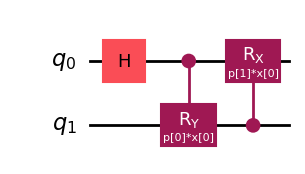

In [2]:
qiskit = QiskitCircuit(qc)

print("Parameter Names:", qiskit.parameter_names)
print("Parameter Dimensions:", qiskit.parameter_dimensions)

qiskit.qiskit_circuit.draw("mpl")

In [3]:
pop = ParameterVector("pop", 2)
operator = QuantumOperator(["ZI", "II"], [pop[0], pop[1]])
operator2 = QuantumOperator(["XI", "IX"], [pop[0], pop[1]])

In [4]:
executor = QiskitExecutor(seed=0, shots=10000)

executor.expectation_value(qc, operator, p=[0.3, 0.5], x=0.1, pop=[0.5, 0.6])

np.float64(1.1)

In [5]:
executor.statevector(qc, p=[0.3, 0.5], x=0.1, pop=[0.5, 0.6])

array([0.70710678+0.j        , 0.70702723+0.j        ,
       0.        -0.00026513j, 0.01060289+0.j        ])

In [6]:
executor.sample(
    qc,
    pop=[0.5, 0.6],
    p=[0.3, 0.5],
    x=0.1,
)

[{'01': 4997, '00': 5003}]

In [7]:
executor.sample(
    qc,
    x=[0.8],
    p=[0.3, 0.5],
)

[{'00': 4969, '01': 4950, '11': 81}]

In [8]:
v = executor.expectation_value_derivatives(
    qc,
    operator,
    "pop",
    "p",
    "",
    "x",
    pop=[0.5, 0.6],
    p=[0.3, 0.5],
    x=0.1,
)
print(v)

{'pop': np.float64(-0.000701904296875), 'p': np.float64(-6.103515625001388e-06), '': np.float64(-0.002764892578125004)}
